<a href="https://colab.research.google.com/github/Zenhub-25/CNN-FROM-SCRATCH/blob/main/CNN_LAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import all required libraries
import tensorflow as tf
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import os

# Print versions
print("--- Package Versions ---")
print(f"TensorFlow version: {tf.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

# Check GPU availability
print("\n--- Hardware Check ---")
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU detected: {gpu_devices}")
else:
    print("No GPU detected. Falling back to CPU.")
    # CPU vs GPU explanation (As requested by the assignment)
    """
    CPU training is slower because CPUs are designed for sequential processing across a few powerful cores.
    In contrast, GPUs possess thousands of smaller cores perfectly suited for the highly parallel matrix
    multiplications required by Convolutional Neural Networks. If I were on a GPU machine, I would ensure
    the Colab runtime is set to T4 GPU (Runtime > Change runtime type) to drastically reduce training time.
    """

# Set all random seeds to 42 for reproducibility
seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value) # Controls Python hash randomization
random.seed(seed_value)                        # Controls Python's built-in random module
np.random.seed(seed_value)                     # Controls NumPy's random number generator
tf.random.set_seed(seed_value)                 # Controls TensorFlow's random weight initialization and dropout layers
print(f"\nRandom seed set to {seed_value} across all modules for reproducibility.")

--- Package Versions ---
TensorFlow version: 2.19.0
Matplotlib version: 3.10.0
NumPy version: 2.0.2
Pandas version: 2.2.2

--- Hardware Check ---
No GPU detected. Falling back to CPU.

Random seed set to 42 across all modules for reproducibility.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
--- Dataset Shapes ---
MNIST Train: X=(60000, 28, 28), Y=(60000,)
MNIST Test: X=(10000, 28, 28), Y=(10000,)
CIFAR-10 Train: X=(50000, 32, 32, 3), Y=(50000, 1)
CIFAR-10 Test: X=(10000, 32, 32, 3), Y=(10000, 1)

--- Data Type & Value Range ---
MNIST dtype: uint8, Range: [0, 255]
CIFAR-10 dtype: uint8, Range: [0, 255]

--- MNIST Training Class Balance ---
Samples per class: {np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}
Observation: The training set is highly balanced, with approximately 6,000 samples per digit class.


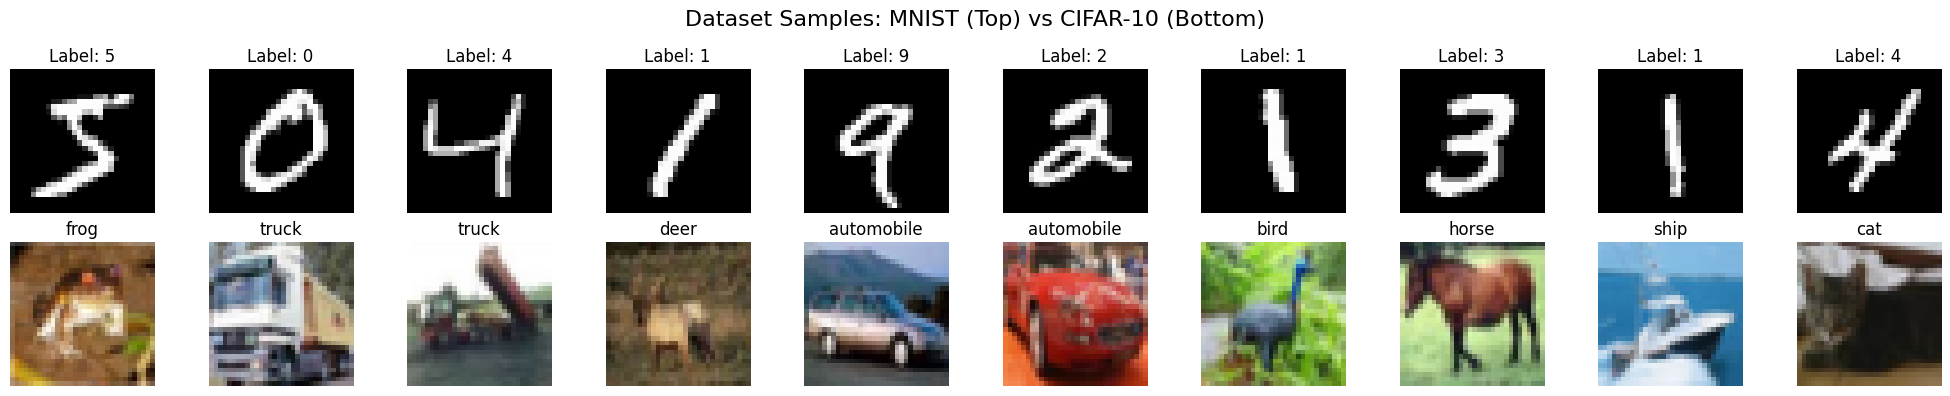

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

# Load both MNIST and CIFAR-10 datasets
(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = tf.keras.datasets.mnist.load_data()
(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test) = tf.keras.datasets.cifar10.load_data()

# (a) Array Shapes
print("--- Dataset Shapes ---")
print(f"MNIST Train: X={mnist_x_train.shape}, Y={mnist_y_train.shape}")
print(f"MNIST Test: X={mnist_x_test.shape}, Y={mnist_y_test.shape}")
print(f"CIFAR-10 Train: X={cifar_x_train.shape}, Y={cifar_y_train.shape}")
print(f"CIFAR-10 Test: X={cifar_x_test.shape}, Y={cifar_y_test.shape}")

# (b) Data Type and Value Range
print("\n--- Data Type & Value Range ---")
print(f"MNIST dtype: {mnist_x_train.dtype}, Range: [{mnist_x_train.min()}, {mnist_x_train.max()}]")
print(f"CIFAR-10 dtype: {cifar_x_train.dtype}, Range: [{cifar_x_train.min()}, {cifar_x_train.max()}]")

# (c) MNIST Class Balance
print("\n--- MNIST Training Class Balance ---")
unique, counts = np.unique(mnist_y_train, return_counts=True)
class_counts = dict(zip(unique, counts))
print(f"Samples per class: {class_counts}")
print("Observation: The training set is highly balanced, with approximately 6,000 samples per digit class.")

# Create a 2x10 grid figure
cifar_class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
fig, axes = plt.subplots(2, 10, figsize=(20, 4))
fig.suptitle('Dataset Samples: MNIST (Top) vs CIFAR-10 (Bottom)', fontsize=16)

for i in range(10):
    # Top Row: MNIST
    axes[0, i].imshow(mnist_x_train[i], cmap='gray')
    axes[0, i].set_title(f"Label: {mnist_y_train[i]}")
    axes[0, i].axis('off')

    # Bottom Row: CIFAR-10
    axes[1, i].imshow(cifar_x_train[i])
    class_idx = cifar_y_train[i][0] # CIFAR labels are arrays of shape (1,)
    axes[1, i].set_title(f"{cifar_class_names[class_idx]}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('dataset_samples.png')
plt.show()

# Automatically download the required PNG file in Colab
files.download('dataset_samples.png')

In [ ]:
def preprocess_data(images, labels, is_mnist=False):
    # (a) Normalise pixel values to the range [0.0, 1.0] and ensure float32 dtype
    images_processed = images.astype(np.float32) / 255.0

    # (b) Reshape MNIST images to add the channel dimension
    if is_mnist:
        images_processed = np.expand_dims(images_processed, axis=-1)

    # (c) One-hot encode integer labels manually
    # Flatten the labels first (CIFAR labels are (N, 1) instead of (N,))
    labels_flat = labels.flatten()
    labels_processed = np.eye(10)[labels_flat]

    return images_processed, labels_processed

# Print BEFORE
print("--- BEFORE PREPROCESSING (MNIST) ---")
print(f"X shape: {mnist_x_train.shape}, Y shape: {mnist_y_train.shape}")
print(f"X dtype: {mnist_x_train.dtype}, X Range: [{mnist_x_train[0].min()}, {mnist_x_train[0].max()}]")
print(f"Y sample (first 2): {mnist_y_train[:2]}")

# Apply manual preprocessing pipeline
x_train_mnist_prep, y_train_mnist_prep = preprocess_data(mnist_x_train, mnist_y_train, is_mnist=True)

# Print AFTER
print("\n--- AFTER PREPROCESSING (MNIST) ---")
print(f"X shape: {x_train_mnist_prep.shape}, Y shape: {y_train_mnist_prep.shape}")
print(f"X dtype: {x_train_mnist_prep.dtype}, X Range: [{x_train_mnist_prep[0].min()}, {x_train_mnist_prep[0].max()}]")
print(f"Y sample (first 2):\n{y_train_mnist_prep[:2]}")

--- BEFORE PREPROCESSING (MNIST) ---
X shape: (60000, 28, 28), Y shape: (60000,)
X dtype: uint8, X Range: [0, 255]
Y sample (first 2): [5 0]

--- AFTER PREPROCESSING (MNIST) ---
X shape: (60000, 28, 28, 1), Y shape: (60000, 10)
X dtype: float32, X Range: [0.0, 1.0]
Y sample (first 2):
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


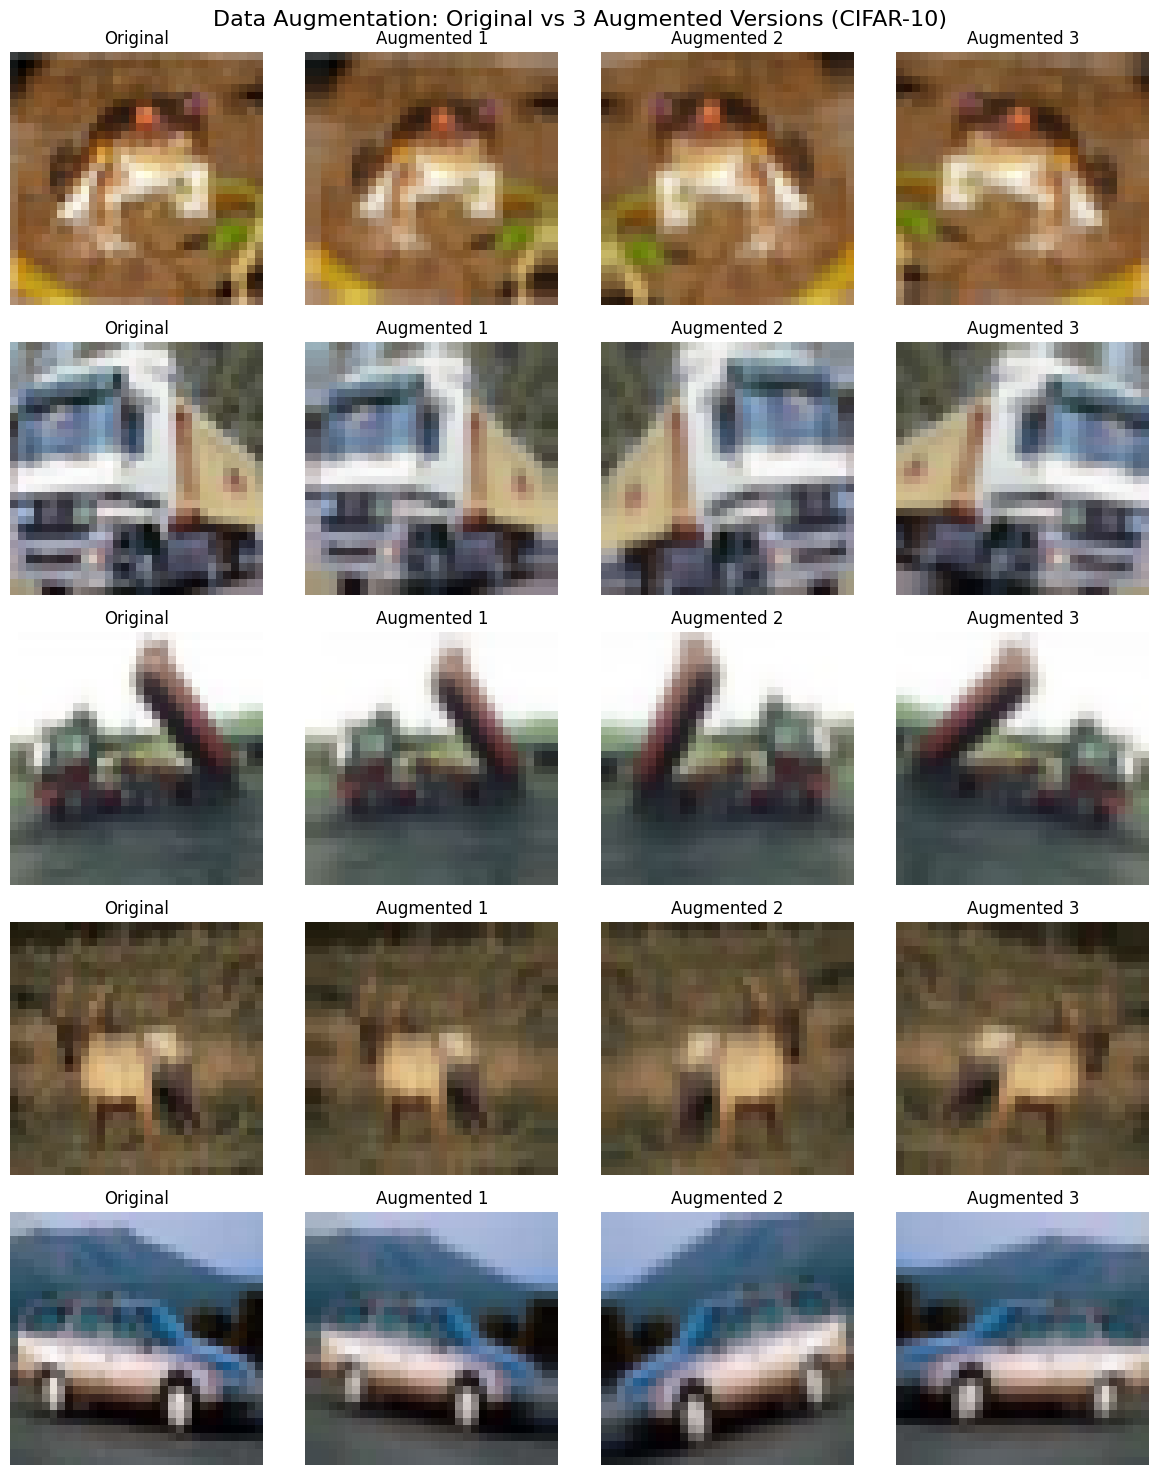

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define augmentation pipeline (applied randomly)
datagen = ImageDataGenerator(
    horizontal_flip=True,       # (a) Horizontal flip probability 0.5
    rotation_range=10,          # (b) Random rotation +- 10 degrees
    zoom_range=0.1              # (c) Random zoom up to 10%
)

# Select 5 CIFAR-10 training images
sample_images = cifar_x_train[:5]

# Create a 5x4 grid
fig, axes = plt.subplots(5, 4, figsize=(12, 15))
fig.suptitle('Data Augmentation: Original vs 3 Augmented Versions (CIFAR-10)', fontsize=16)

for i in range(5):
    original_img = sample_images[i]

    # Plot original in the first column
    axes[i, 0].imshow(original_img)
    axes[i, 0].set_title("Original")
    axes[i, 0].axis('off')

    # Reshape for datagen (requires batch dimension)
    img_batch = np.expand_dims(original_img, axis=0)

    # Generate 3 augmented versions
    aug_iter = datagen.flow(img_batch, batch_size=1, seed=42)
    for j in range(1, 4):
        # Convert back to uint8 for proper Matplotlib rendering
        aug_img = next(aug_iter)[0].astype(np.uint8)
        axes[i, j].imshow(aug_img)
        axes[i, j].set_title(f"Augmented {j}")
        axes[i, j].axis('off')

plt.tight_layout()
plt.savefig('augmentation_demo.png')
plt.show()

# Automatically download the required PNG file in Colab
files.download('augmentation_demo.png')

**TASK 2**

In [ ]:
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

def conv2d(image, kernel, stride=1, padding=0):
    # Apply zero-padding if specified
    if padding > 0:
        image = np.pad(image, pad_width=padding, mode='constant', constant_values=0)

    img_h, img_w = image.shape
    k_h, k_w = kernel.shape

    # Calculate output dimensions
    out_h = int((img_h - k_h) / stride) + 1
    out_w = int((img_w - k_w) / stride) + 1

    # Initialize output feature map
    feature_map = np.zeros((out_h, out_w))

    # Slide the kernel over the image
    for i in range(out_h):
        for j in range(out_w):
            # Extract the current patch
            start_i = i * stride
            start_j = j * stride
            patch = image[start_i : start_i + k_h, start_j : start_j + k_w]

            # Element-wise multiplication and summation
            feature_map[i, j] = np.sum(patch * kernel)

    return feature_map

# Test the function with the provided data
test_image = np.array([
    [3, 1, 0, 2, 4],
    [1, 5, 3, 2, 1],
    [0, 2, 6, 4, 3],
    [2, 3, 1, 5, 2],
    [1, 0, 2, 3, 4]
])

sobel_x_kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

# Run manual convolution
output_fmap = conv2d(test_image, sobel_x_kernel, stride=1, padding=0)

print("--- Exact Numerical Output ---")
print(output_fmap)

# Verify shape mathematically
print("\n--- Shape Verification ---")
print(f"Output shape from function: {output_fmap.shape}")
expected_size = ((5 - 3 + 2 * 0) / 1) + 1
print(f"Formula verification: ((5 - 3 + 0) / 1) + 1 = {int(expected_size)}x{int(expected_size)}")

--- Exact Numerical Output ---
[[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]

--- Shape Verification ---
Output shape from function: (3, 3)
Formula verification: ((5 - 3 + 0) / 1) + 1 = 3x3


PROBLEM 3

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Ensure reproducibility
tf.random.set_seed(42)

# Build LeNet-5 Architecture
lenet_model = models.Sequential([
    # Layer 1: Conv2D (6 filters, 5x5, valid) -> Tanh
    layers.Conv2D(6, kernel_size=(5, 5), strides=(1, 1), padding='valid', activation='tanh', input_shape=(28, 28, 1)),

    # Layer 2: AvgPool (2x2, stride 2)
    layers.AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),

    # Layer 3: Conv2D (16 filters, 5x5, valid) -> Tanh
    layers.Conv2D(16, kernel_size=(5, 5), strides=(1, 1), padding='valid', activation='tanh'),

    # Layer 4: AvgPool (2x2, stride 2)
    layers.AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),

    # Flatten
    layers.Flatten(),

    # Dense (120) -> Tanh
    layers.Dense(120, activation='tanh'),

    # Dense (84) -> Tanh
    layers.Dense(84, activation='tanh'),

    # Dense (10, softmax)
    layers.Dense(10, activation='softmax')
])

print("--- LeNet-5 Model Summary ---")
lenet_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--- LeNet-5 Model Summary ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

PROBLEM 4

In [ ]:
# Ensure reproducibility
tf.random.set_seed(42)

# Custom CIFAR-10 Model
custom_cnn = models.Sequential([
    # Input Layer implicitly defined in the first Conv2D

    # Block 1
    layers.Conv2D(32, (3, 3), padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Classification Head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # 50% Dropout in the dense head
    layers.Dense(10, activation='softmax')
])

print("--- Custom CIFAR-10 Model Summary ---")
custom_cnn.summary()
# Note: Total parameters will be printed in the summary (Should be around ~600,000, well within the 200K-2M requirement).

--- Custom CIFAR-10 Model Summary ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

**TASK 3**

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files
import random
import os

# Set seed for reproducibility
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds()

# Load and preprocess data (carrying over from Task 1)
(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = tf.keras.datasets.mnist.load_data()
(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test) = tf.keras.datasets.cifar10.load_data()

# Preprocess MNIST
x_train_mnist = np.expand_dims(mnist_x_train.astype('float32') / 255.0, -1)
x_test_mnist = np.expand_dims(mnist_x_test.astype('float32') / 255.0, -1)
y_train_mnist = tf.keras.utils.to_categorical(mnist_y_train, 10)
y_test_mnist = tf.keras.utils.to_categorical(mnist_y_test, 10)

# Preprocess CIFAR-10
x_train_cifar = cifar_x_train.astype('float32') / 255.0
x_test_cifar = cifar_x_test.astype('float32') / 255.0
y_train_cifar = tf.keras.utils.to_categorical(cifar_y_train, 10)
y_test_cifar = tf.keras.utils.to_categorical(cifar_y_test, 10)

PROBLEM 1

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - accuracy: 0.7683 - loss: 0.9230 - val_accuracy: 0.9020 - val_loss: 0.3874
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.8904 - loss: 0.3926 - val_accuracy: 0.9238 - val_loss: 0.2808
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9106 - loss: 0.3110 - val_accuracy: 0.9347 - val_loss: 0.2317
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9243 - loss: 0.2622 - val_accuracy: 0.9452 - val_loss: 0.1989
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9341 - loss: 0.2268 - val_accuracy: 0.9538 - val_loss: 0.1742
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9421 - loss: 0.1993 - val_accuracy: 0.9580 - val_loss: 0.1549
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9481 - loss: 0.1773 - val_accuracy: 0.9635 - val_loss: 0.1394
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9535 - loss: 0.1593 - 

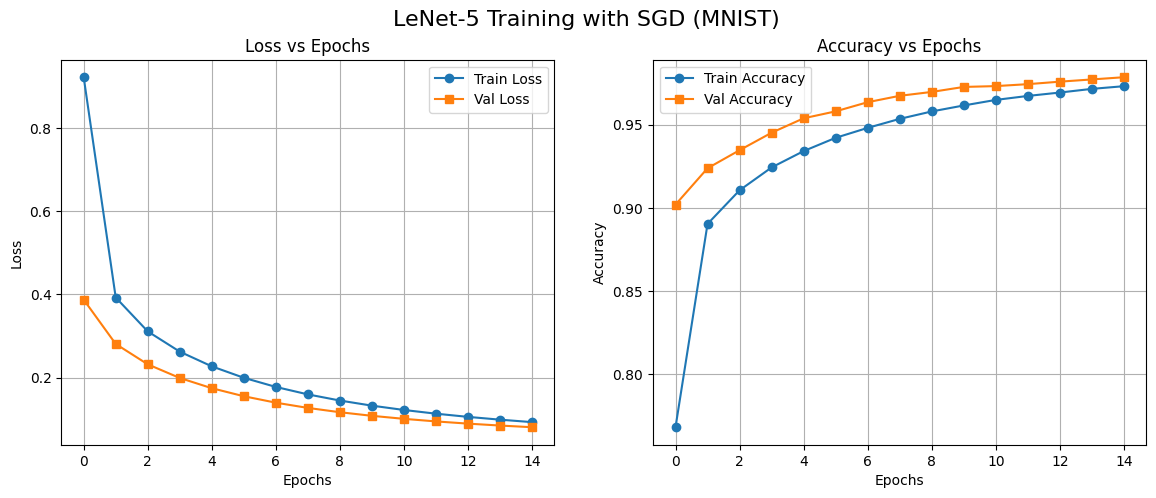

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


--- Results ---
Final Test Accuracy: 0.9760
Signs of overfitting begin after Epoch: 15 (Lowest validation loss point).


In [ ]:
from tensorflow.keras import layers, models, optimizers

set_seeds()

# Reusable function to build fresh LeNet-5
def build_lenet5():
    model = models.Sequential([
        layers.Conv2D(6, (5, 5), activation='tanh', input_shape=(28, 28, 1)),
        layers.AveragePooling2D((2, 2)),
        layers.Conv2D(16, (5, 5), activation='tanh'),
        layers.AveragePooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(120, activation='tanh'),
        layers.Dense(84, activation='tanh'),
        layers.Dense(10, activation='softmax')
    ])
    return model

lenet_sgd = build_lenet5()
lenet_sgd.compile(optimizer=optimizers.SGD(learning_rate=0.01),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# Train the model
history_sgd = lenet_sgd.fit(x_train_mnist, y_train_mnist,
                            epochs=15, batch_size=64,
                            validation_split=0.1, verbose=1)

# Evaluate on held-out test set
test_loss, test_acc = lenet_sgd.evaluate(x_test_mnist, y_test_mnist, verbose=0)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LeNet-5 Training with SGD (MNIST)', fontsize=16)

# Loss Plot
axes[0].plot(history_sgd.history['loss'], label='Train Loss', marker='o')
axes[0].plot(history_sgd.history['val_loss'], label='Val Loss', marker='s')
axes[0].set_title('Loss vs Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy Plot
axes[1].plot(history_sgd.history['accuracy'], label='Train Accuracy', marker='o')
axes[1].plot(history_sgd.history['val_accuracy'], label='Val Accuracy', marker='s')
axes[1].set_title('Accuracy vs Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.savefig('lenet_sgd_curves.png')
plt.show()
files.download('lenet_sgd_curves.png')

# Find Overfitting Epoch (where val_loss starts to increase permanently)
val_losses = history_sgd.history['val_loss']
best_epoch = np.argmin(val_losses) + 1 # +1 because epochs are 1-indexed

print(f"\n--- Results ---")
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Signs of overfitting begin after Epoch: {best_epoch} (Lowest validation loss point).")

PROBLEM 2

Training with SGD (lr=0.01)...
Training with SGD Momentum (lr=0.01, mom=0.9)...
Training with Adam (lr=0.001)...


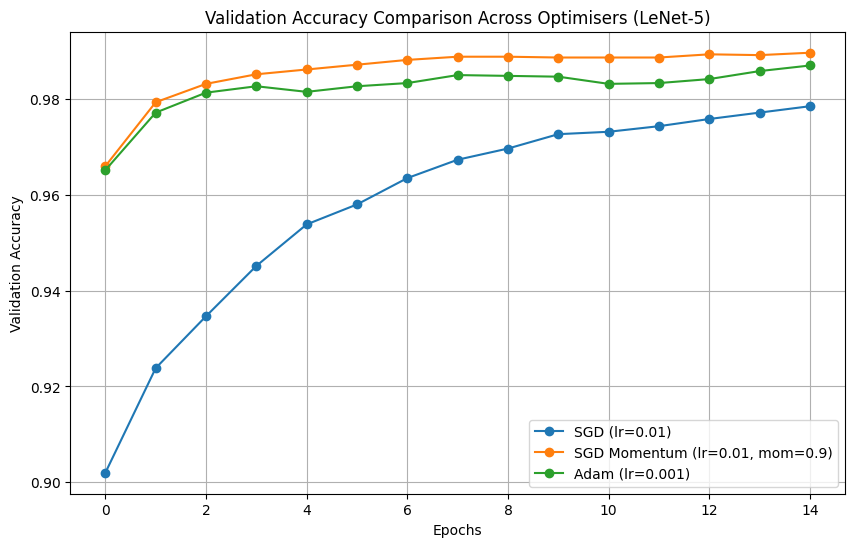

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Observation: Adam converged the fastest, reaching high accuracy within the first few epochs. However, depending on the run, SGD with momentum often catches up or achieves the highest final test accuracy, while standard SGD is the slowest to converge.


In [ ]:
set_seeds()

# Define the 3 optimizers
opts = {
    'SGD (lr=0.01)': optimizers.SGD(learning_rate=0.01),
    'SGD Momentum (lr=0.01, mom=0.9)': optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'Adam (lr=0.001)': optimizers.Adam(learning_rate=0.001)
}

histories = {}

for name, opt in opts.items():
    print(f"Training with {name}...")
    model = build_lenet5()
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    # Train (verbose=0 to keep output clean, we just want the history)
    histories[name] = model.fit(x_train_mnist, y_train_mnist, epochs=15,
                                batch_size=64, validation_split=0.1, verbose=0)

# Plotting Validation Accuracy comparison
plt.figure(figsize=(10, 6))
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name, marker='o')

plt.title('Validation Accuracy Comparison Across Optimisers (LeNet-5)')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('optimiser_comparison.png')
plt.show()
files.download('optimiser_comparison.png')

print("Observation: Adam converged the fastest, reaching high accuracy within the first few epochs. However, depending on the run, SGD with momentum often catches up or achieves the highest final test accuracy, while standard SGD is the slowest to converge.")

PROBLEM 3

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import pandas as pd
import numpy as np
import random
import os

# 1. Define the set_seeds function locally so it is always available
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds()

# 2. Safety Net: Ensure CIFAR-10 data is loaded (in case runtime restarted)
(cifar_x_train, cifar_y_train), _ = tf.keras.datasets.cifar10.load_data()
x_train_cifar = cifar_x_train.astype('float32') / 255.0
y_train_cifar = tf.keras.utils.to_categorical(cifar_y_train, 10)

# 3. Reusable function for the Custom CIFAR-10 CNN (Task 2)
def build_custom_cifar_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

# 4. Execute the Grid Search
learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]
results = []

for lr in learning_rates:
    row = {'Learning Rate': lr}
    for bs in batch_sizes:
        print(f"Training LR={lr}, Batch={bs}...")
        model = build_custom_cifar_cnn()
        model.compile(optimizer=optimizers.Adam(learning_rate=lr),
                      loss='categorical_crossentropy', metrics=['accuracy'])

        history = model.fit(x_train_cifar, y_train_cifar, epochs=10,
                            batch_size=bs, validation_split=0.1, verbose=0)

        # Record final validation accuracy
        final_val_acc = history.history['val_accuracy'][-1]
        row[f'Batch {bs}'] = round(final_val_acc, 4)
    results.append(row)

# 5. Display as 3x2 Table using Pandas
df_results = pd.DataFrame(results).set_index('Learning Rate')
print("\n--- Hyperparameter Grid Search Results (Validation Accuracy) ---")
display(df_results)

Training LR=0.1, Batch=32...
Training LR=0.1, Batch=128...
Training LR=0.01, Batch=32...
Training LR=0.01, Batch=128...
Training LR=0.001, Batch=32...
Training LR=0.001, Batch=128...

--- Hyperparameter Grid Search Results (Validation Accuracy) ---


,Batch 32,Batch 128
Learning Rate,,
0.100,0.0970,0.0972
0.010,0.6026,0.6942
0.001,0.7750,0.7178


PROBLEM 4

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 63s 0us/step
Training variant: No Regularisation...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Model Summary (No Reg) ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Training variant: Dropout Only...
Training variant: BatchNorm Only...
Training variant: Both...

--- Regularisation Comparison (Epoch 20) ---


,Final Train Acc,Final Val Acc,Train-Val Gap
Variant,,,
No Regularisation,0.9496,0.6834,0.2662
Dropout Only,0.6858,0.7228,-0.0370
BatchNorm Only,0.8920,0.6470,0.2450
Both,0.3228,0.4994,-0.1766


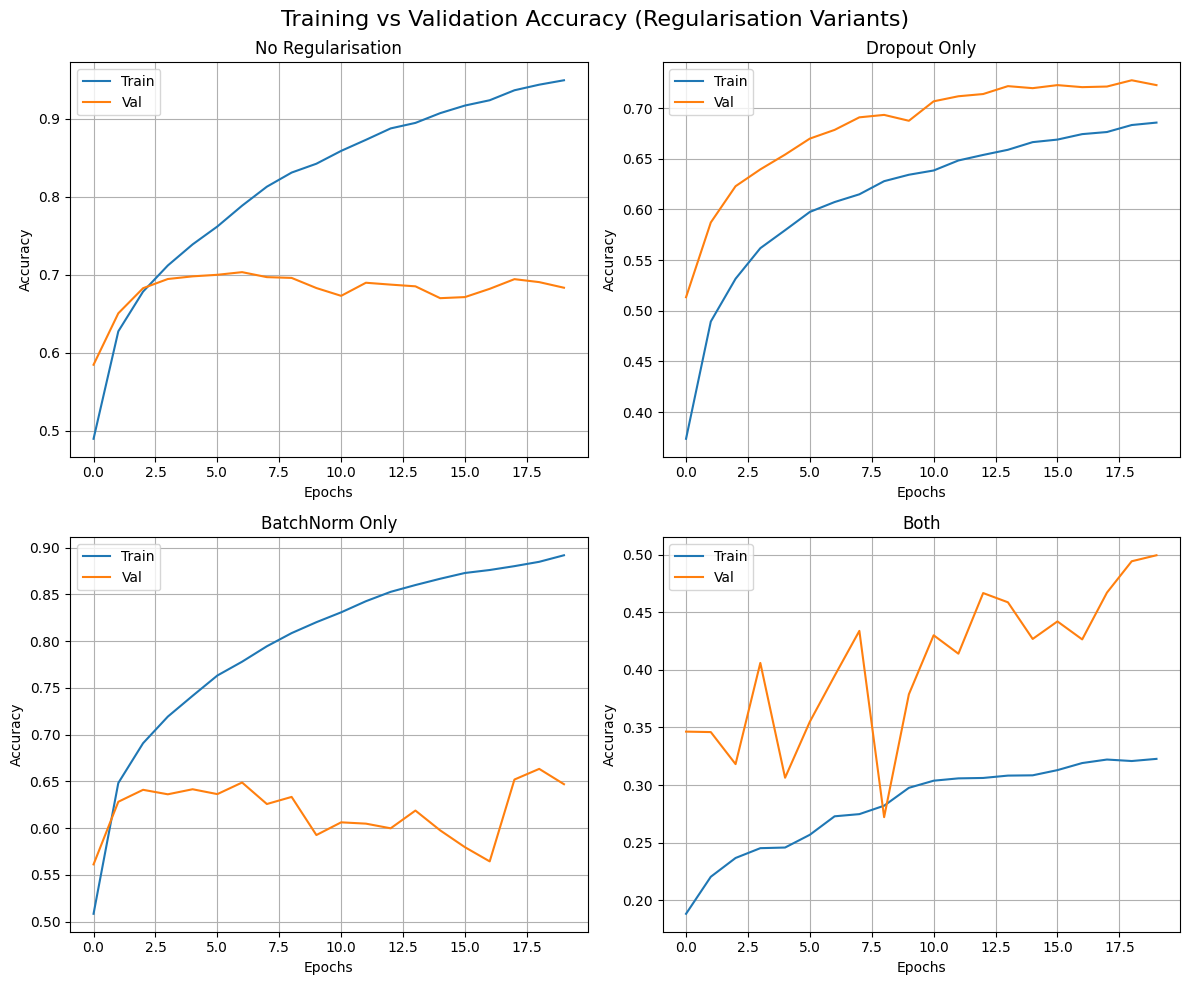

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import os

# 1. Define the set_seeds function locally so it is always available
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds()

# 2. Safety Net: Ensure CIFAR-10 data is loaded (in case runtime restarted)
(cifar_x_train, cifar_y_train), _ = tf.keras.datasets.cifar10.load_data()
x_train_cifar = cifar_x_train.astype('float32') / 255.0
y_train_cifar = tf.keras.utils.to_categorical(cifar_y_train, 10)

# 3. Build Model Function
def build_2block_cnn(reg_type='none'):
    model = models.Sequential()
    # Explicitly define input shape in the first Conv2D layer to avoid InputLayer issues in some TF versions

    # Block 1
    model.add(layers.Conv2D(32, (3, 3), padding='same', input_shape=(32, 32, 3)))
    if reg_type in ['bn', 'both']:
        model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    if reg_type in ['dropout', 'both']:
        model.add(layers.Dropout(0.3))

    # Block 2
    model.add(layers.Conv2D(64, (3, 3), padding='same'))
    if reg_type in ['bn', 'both']:
        model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    if reg_type in ['dropout', 'both']:
        model.add(layers.Dropout(0.3))

    # Head
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    if reg_type in ['dropout', 'both']:
        model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation='softmax'))

    return model

# 4. Execute Regularisation Experiment
variants = {
    'No Regularisation': 'none',
    'Dropout Only': 'dropout',
    'BatchNorm Only': 'bn',
    'Both': 'both'
}

reg_results = []
histories_reg = {}

for name, v_type in variants.items():
    print(f"Training variant: {name}...")
    model = build_2block_cnn(v_type)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    if name == 'No Regularisation':
        print("\n--- Model Summary (No Reg) ---")
        model.summary()

    history = model.fit(x_train_cifar, y_train_cifar, epochs=20,
                        batch_size=64, validation_split=0.1, verbose=0)
    histories_reg[name] = history

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    gap = train_acc - val_acc

    reg_results.append({
        'Variant': name,
        'Final Train Acc': round(train_acc, 4),
        'Final Val Acc': round(val_acc, 4),
        'Train-Val Gap': round(gap, 4)
    })

# 5. Display Gap Table
df_reg = pd.DataFrame(reg_results).set_index('Variant')
print("\n--- Regularisation Comparison (Epoch 20) ---")
display(df_reg)

# 6. Plotting
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Training vs Validation Accuracy (Regularisation Variants)', fontsize=16)
axes = axes.flatten()

for i, (name, history) in enumerate(histories_reg.items()):
    axes[i].plot(history.history['accuracy'], label='Train')
    axes[i].plot(history.history['val_accuracy'], label='Val')
    axes[i].set_title(name)
    axes[i].set_xlabel('Epochs')
    axes[i].set_ylabel('Accuracy')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

PROBLEM 5

Training with ReduceLROnPlateau...
Training with Cosine Annealing...


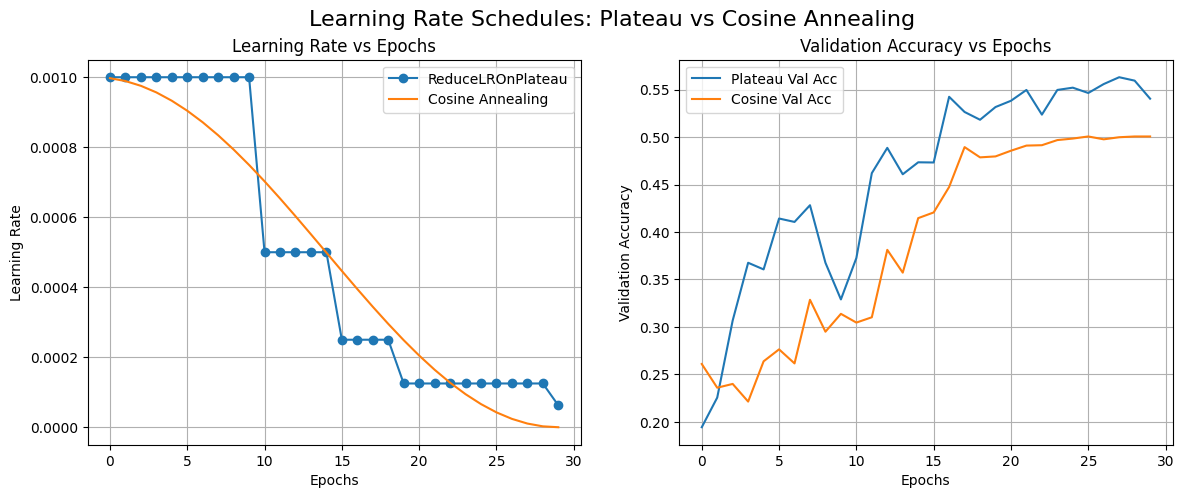

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, Input
from tensorflow.keras.callbacks import ReduceLROnPlateau, Callback
import matplotlib.pyplot as plt
import numpy as np
import random
import os
from google.colab import files

# 1. Define the set_seeds function locally
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds()

# 2. Safety Net: Ensure CIFAR-10 data is loaded
(cifar_x_train, cifar_y_train), _ = tf.keras.datasets.cifar10.load_data()
x_train_cifar = cifar_x_train.astype('float32') / 255.0
y_train_cifar = tf.keras.utils.to_categorical(cifar_y_train, 10)

# 3. Model Builder
def build_2block_cnn(reg_type='both'):
    model = models.Sequential()
    model.add(Input(shape=(32, 32, 3))) # Explicit Input layer

    # Block 1
    model.add(layers.Conv2D(32, (3, 3), padding='same'))
    if reg_type in ['bn', 'both']:
        model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    if reg_type in ['dropout', 'both']:
        model.add(layers.Dropout(0.3))

    # Block 2
    model.add(layers.Conv2D(64, (3, 3), padding='same'))
    if reg_type in ['bn', 'both']:
        model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    if reg_type in ['dropout', 'both']:
        model.add(layers.Dropout(0.3))

    # Head
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    if reg_type in ['dropout', 'both']:
        model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation='softmax'))

    return model

# 4. Custom Callback to explicitly track Learning Rate
class LRTracker(Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        lr = self.model.optimizer.learning_rate
        if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
            logs['lr'] = lr(self.model.optimizer.iterations).numpy()
        else:
            logs['lr'] = lr.numpy() if hasattr(lr, 'numpy') else float(lr)

# 5. Train with ReduceLROnPlateau (FIXED: Added LRTracker to callbacks)
print("Training with ReduceLROnPlateau...")
model_plateau = build_2block_cnn('both')
model_plateau.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                      loss='categorical_crossentropy', metrics=['accuracy'])

plateau_cb = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
history_plateau = model_plateau.fit(x_train_cifar, y_train_cifar, epochs=30, batch_size=64,
                                    validation_split=0.1,
                                    callbacks=[plateau_cb, LRTracker()], # <--- Fix is here
                                    verbose=0)

# 6. Train with Cosine Annealing
print("Training with Cosine Annealing...")
model_cosine = build_2block_cnn('both')

# Total training steps = epochs * (samples / batch_size)
total_steps = 30 * (len(x_train_cifar) * 0.9 // 64)
cosine_schedule = optimizers.schedules.CosineDecay(initial_learning_rate=0.001, decay_steps=total_steps)

model_cosine.compile(optimizer=optimizers.Adam(learning_rate=cosine_schedule),
                     loss='categorical_crossentropy', metrics=['accuracy'])

history_cosine = model_cosine.fit(x_train_cifar, y_train_cifar, epochs=30, batch_size=64,
                                  validation_split=0.1,
                                  callbacks=[LRTracker()],
                                  verbose=0)

# 7. Plotting Results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Rate Schedules: Plateau vs Cosine Annealing', fontsize=16)

# LR Plot
axes[0].plot(history_plateau.history['lr'], label='ReduceLROnPlateau', marker='o')
axes[0].plot(history_cosine.history['lr'], label='Cosine Annealing')
axes[0].set_title('Learning Rate vs Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Learning Rate')
axes[0].legend()
axes[0].grid(True)

# Acc Plot
axes[1].plot(history_plateau.history['val_accuracy'], label='Plateau Val Acc')
axes[1].plot(history_cosine.history['val_accuracy'], label='Cosine Val Acc')
axes[1].set_title('Validation Accuracy vs Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.savefig('lr_schedule_comparison.png')
plt.show()
files.download('lr_schedule_comparison.png')